# ANALISIS EXPLORATORIO DE DATOS

#### Importamos librerias

In [9]:
import os
import sys
from pathlib import Path


def find_project_root(marker="requirements.txt"):
    """Busca el directorio del proyecto incluso si el notebook se abre desde Downloads o desde otra carpeta."""
    current = Path.cwd().resolve()

    for base in [current, *current.parents]:
        if (base / marker).exists():
            return base

    search_roots = [Path.home() / "Documents", Path.home()]
    for root in search_roots:
        if not root.exists():
            continue
        for candidate in root.rglob(marker):
            candidate = candidate.parent.resolve()
            if (candidate / "utils").exists() and (candidate / "src").exists():
                return candidate

    return current


PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", find_project_root())).resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

!{sys.executable} -m pip install -r "{PROJECT_ROOT / 'requirements.txt'}"



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
#

import re
import uuid
import warnings

import chromadb
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
from wordcloud import STOPWORDS, WordCloud

from utils.chunk_functions import *
from utils.plot_functions import *

pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 22232.06it/s]


# Inspeccionamos el dataset

In [11]:
df = pd.read_csv(PROJECT_ROOT / "src" / "data" / "Reviews.csv")

In [12]:
#Inspeccionamos las primeras 5 filas para hacernos una idea rápida del mismo.
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this w...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in thi..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taff...


In [13]:
#Chequeo de columnas
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [14]:
#Buscamos si hay nulos
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Como estrategia para imputar los nulos, decidimos llenarlos con un valor predeterminado y no con por ejemplo, la moda ya que podría sesgar las columnas

In [15]:
df['ProfileName'] = df['ProfileName'].fillna('UNKNOWN_USER')
df['Summary'] = df['Summary'].fillna('NO SUMMARY')

In [16]:
from html import unescape


def clean_text_vectorized(series: pd.Series) -> pd.Series:
    """Misma lógica que la limpieza original, pero vectorizada con
    operaciones .str en vez de .apply(fila por fila). Sobre ~568k filas la
    versión con .apply llegaba a colgarse (en una corrida anterior esta
    celda terminó en KeyboardInterrupt); esta versión es mucho más rápida."""
    s = series.fillna("").astype(str)
    s = s.map(unescape)  # entidades HTML como &amp; (no hay equivalente vectorizado)
    s = s.str.replace(r"<[^>]+>", " ", regex=True)             # tags HTML
    s = s.str.replace(r"http\S+|www\.\S+", " ", regex=True)  # URLs
    s = s.str.replace(r"\S+@\S+", " ", regex=True)             # emails
    s = s.str.replace(r"@\w+|#\w+", " ", regex=True)           # menciones y hashtags
    s = s.str.replace(r"[^\w\s.,;:!?()-]", " ", regex=True, flags=re.UNICODE)  # caracteres raros
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s.str.lower()


df["Text_clean"] = clean_text_vectorized(df["Text"])
df["Summary_clean"] = clean_text_vectorized(df["Summary"])
df["full_text_clean"] = (df["Text_clean"].radd(df["Summary_clean"] + " ")).str.strip()

In [17]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Text_clean,Summary_clean,full_text_clean
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pr...,i have bought several of the vitality canned dog food products and have found them all to be of good quality. the pr...,good quality dog food,good quality dog food i have bought several of the vitality canned dog food products and have found them all to be o...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this w...,product arrived labeled as jumbo salted peanuts...the peanuts were actually small sized unsalted. not sure if this w...,not as advertised,not as advertised product arrived labeled as jumbo salted peanuts...the peanuts were actually small sized unsalted. ...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in thi...","this is a confection that has been around a few centuries. it is a light, pillowy citrus gelatin with nuts - in this...",delight says it all,"delight says it all this is a confection that has been around a few centuries. it is a light, pillowy citrus gelatin..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the...,if you are looking for the secret ingredient in robitussin i believe i have found it. i got this in addition to the ...,cough medicine,cough medicine if you are looking for the secret ingredient in robitussin i believe i have found it. i got this in a...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taff...,great taffy at a great price. there was a wide assortment of yummy taffy. delivery was very quick. if your a taffy l...,great taffy,great taffy great taffy at a great price. there was a wide assortment of yummy taffy. delivery was very quick. if yo...


In [18]:
df["review_length_clean"] = df["Text_clean"].str.split().str.len()
df["summary_length_clean"] = df["Summary_clean"].str.split().str.len()

In [19]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
Text_clean                0
Summary_clean             0
full_text_clean           0
review_length_clean       0
summary_length_clean      0
dtype: int64

In [20]:
df["Time"] = pd.to_datetime(df["Time"], unit="s")

In [21]:
#Obtenemos más descripción e información del DataFrame
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype        
---  ------                  --------------   -----        
 0   Id                      568454 non-null  int64        
 1   ProductId               568454 non-null  str          
 2   UserId                  568454 non-null  str          
 3   ProfileName             568454 non-null  str          
 4   HelpfulnessNumerator    568454 non-null  int64        
 5   HelpfulnessDenominator  568454 non-null  int64        
 6   Score                   568454 non-null  int64        
 7   Time                    568454 non-null  datetime64[s]
 8   Summary                 568454 non-null  str          
 9   Text                    568454 non-null  str          
 10  Text_clean              568454 non-null  str          
 11  Summary_clean           568454 non-null  str          
 12  full_text_clean         568454 non-null  str          


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,review_length_clean,summary_length_clean
count,568454.000000,568454.000000,568454.00000,568454.000000,568454,568454.000000,568454.000000
mean,284227.500000,1.743817,2.22881,4.183199,2011-01-28 23:16:44,81.380423,4.170211
min,1.000000,0.000000,0.00000,1.000000,1999-10-08 00:00:00,3.000000,0.000000
25%,142114.250000,0.000000,0.00000,4.000000,2010-04-15 00:00:00,34.000000,2.000000
50%,284227.500000,0.000000,1.00000,5.000000,2011-07-20 00:00:00,57.000000,4.000000
75%,426340.750000,2.000000,2.00000,5.000000,2012-03-26 00:00:00,99.000000,5.000000
max,568454.000000,866.000000,923.00000,5.000000,2012-10-26 00:00:00,3448.000000,42.000000
std,164098.679298,7.636513,8.28974,1.310436,NaN,80.103093,2.656406


## Creamos Variables Auxiliares para los gráficos

In [22]:
# Variables auxiliares para gráficos y análisis
# review_length_clean / summary_length_clean ya se calcularon más arriba;
# acá solo agregamos lo que falta, sin volver a tokenizar el texto de nuevo.
df["review_length"] = df["review_length_clean"]
df["summary_length"] = df["summary_length_clean"]

df["helpfulness_ratio"] = (
    df["HelpfulnessNumerator"].astype(float) /
    df["HelpfulnessDenominator"].replace(0, np.nan)
).fillna(0.0)

df["full_text"] = (
    df["Summary_clean"].fillna("") + " " + df["Text_clean"].fillna("")
).str.strip()

# EDA

#### Distribuciones Univariadas

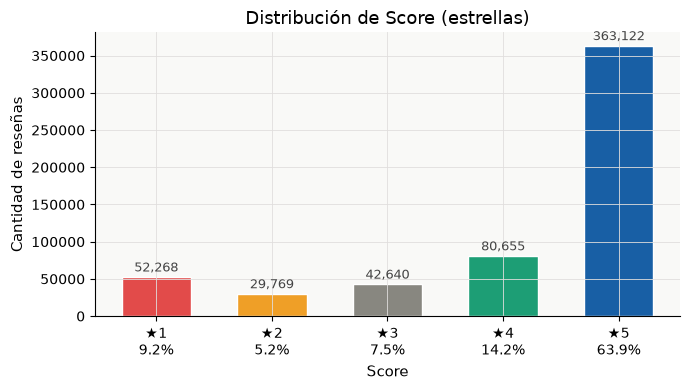

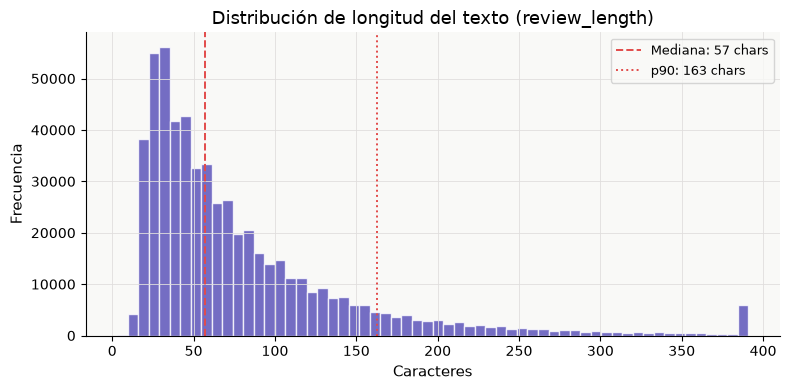

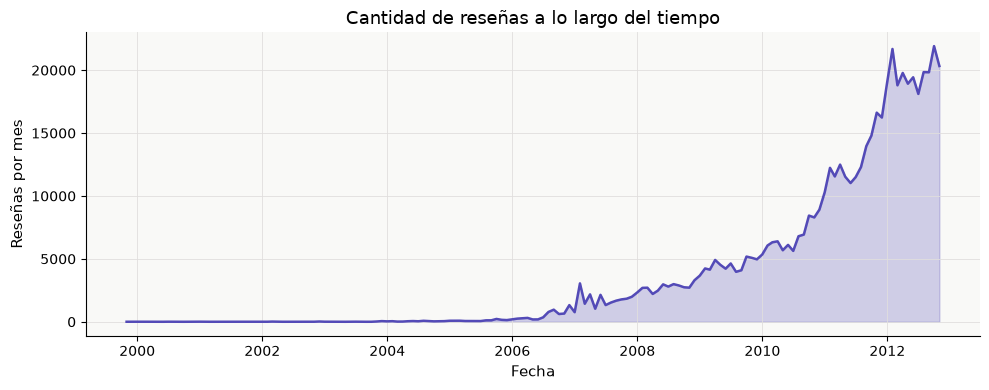

In [23]:
df_score = plot_score_distribution(df)
df_longitud_texto = plot_text_length_distribution(df)
df_grafico_3 = plot_reviews_over_time(df)

#### Variables Categóricas

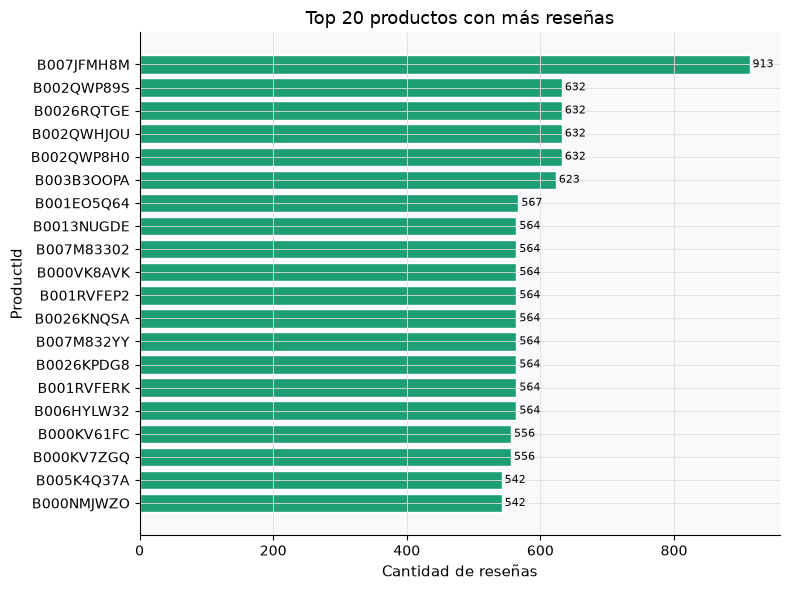

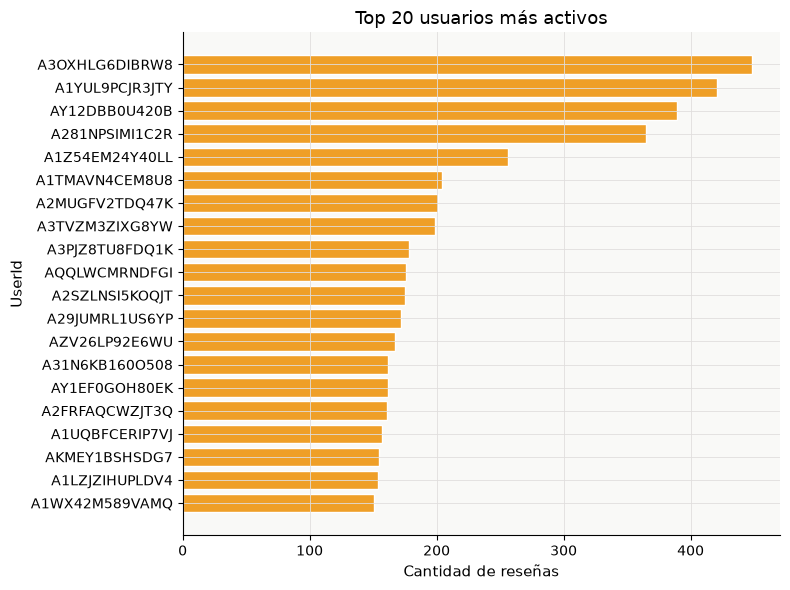

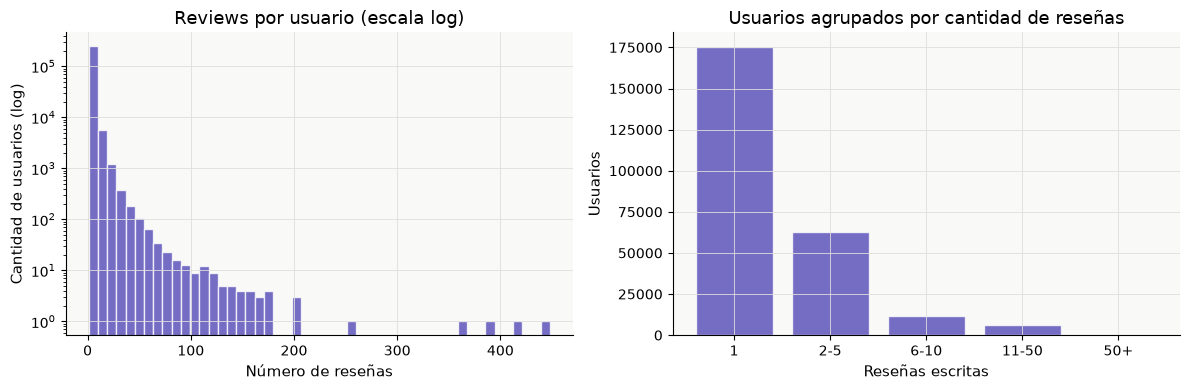

In [24]:
df_graf = plot_top_products(df)
df_graf_2 = plot_top_users(df)
df_graf_3 = plot_reviews_per_user_distribution(df)

#### Helpfulness

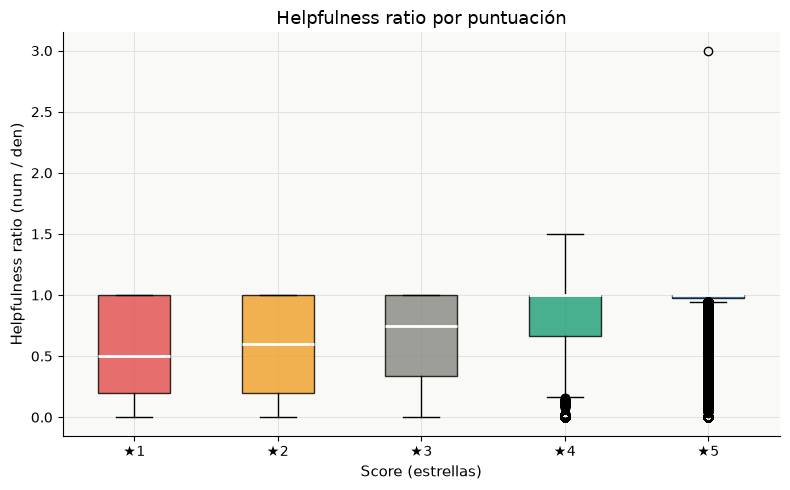

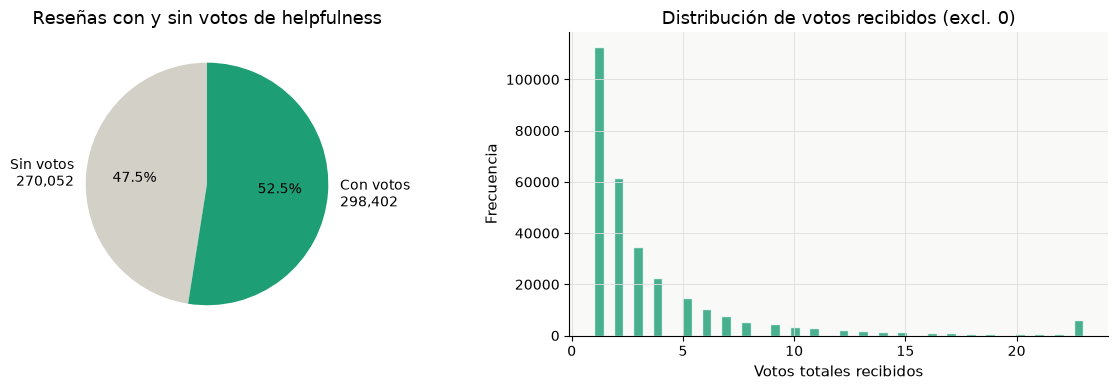

In [25]:
graficos_text = plot_helpfulness_ratio_by_score(df)
graficos_text_1 = plot_denominator_distribution(df)

## Muestra de desarrollo para probar el pipeline

No recomiendo filtrar a 250 registros, porque el proceso genera una descripción por producto y no por fila. Es mejor tomar una muestra de productos con varias reviews, por ejemplo 250 productos con al menos 3 reseñas cada uno.


In [26]:
# Observamos la cantidad de filas y columnas que tiene el dataframe
print(f"Shape del dataset: {df.shape}")

# Estrategia recomendada para desarrollo: muestreo por productos, no por filas.
product_counts = df.groupby("ProductId").size().reset_index(name="n_reviews")
product_counts.head()

Shape del dataset: (568454, 19)


,ProductId,n_reviews
0,0006641040,37
1,141278509X,1
2,2734888454,2
3,2841233731,1
4,7310172001,173


In [27]:
# Estrategia recomendada para desarrollo
# 1) Cargar de nuevo el dataset base para no depender de una muestra previa.
# 2) Agrupar por producto porque un ProductId puede tener muchas reviews.
# 3) Quedarnos con productos que tengan al menos 6 reviews.
# 4) Tomar los 250 productos con más reviews (y mejor score entre empates).
#
# Nota: esto NO es un muestreo aleatorio a propósito. El golden_set de la
# sección de Chunking está armado sobre productos con muchas reviews (p. ej.
# B007JFMH8M), así que ordenar por n_reviews es lo que garantiza que esos
# productos queden incluidos en esta muestra de desarrollo. Si en algún
# momento se cambia este criterio por un muestreo aleatorio, hay que
# asegurarse por separado de que los ProductId del golden_set sigan estando.

product_stats = (
    df.groupby("ProductId")
      .agg(
          n_reviews=("ProductId", "size"),
          avg_score=("Score", "mean"),
          avg_helpfulness=("helpfulness_ratio", "mean"),
      )
      .reset_index()
)

eligible_products = product_stats[product_stats["n_reviews"] >= 6]

sample_product_ids = (
    eligible_products
    .sort_values(["n_reviews", "avg_score"], ascending=[False, False])
    .head(250)["ProductId"]
    .tolist()
)

df_dev = df[df["ProductId"].isin(sample_product_ids)].copy()

print(f"Filas originales: {len(df)}")
print(f"Productos elegibles: {len(eligible_products)}")
print(f"Filas en la muestra de desarrollo: {len(df_dev)}")
print(f"Productos en la muestra de desarrollo: {df_dev['ProductId'].nunique()}")
print("\nTop productos por cantidad de reviews:")
print(eligible_products.sort_values("n_reviews", ascending=False).head(10))

Filas originales: 568454
Productos elegibles: 17310
Filas en la muestra de desarrollo: 86565
Productos en la muestra de desarrollo: 250

Top productos por cantidad de reviews:
        ProductId  n_reviews  avg_score  avg_helpfulness
71170  B007JFMH8M        913   4.582694         0.031581
42264  B002QWP8H0        632   4.588608         0.218921
42263  B002QWP89S        632   4.588608         0.218921
42257  B002QWHJOU        632   4.588608         0.218921
37898  B0026RQTGE        632   4.588608         0.218921
46205  B003B3OOPA        623   4.739968         0.635797
28624  B001EO5Q64        567   4.746032         0.538625
35244  B001RVFERK        564   4.310284         0.302391
37794  B0026KNQSA        564   4.310284         0.302391
20497  B000VK8AVK        564   4.310284         0.302391


In [28]:
df_dev.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Text_clean,Summary_clean,full_text_clean,review_length_clean,summary_length_clean,review_length,summary_length,helpfulness_ratio,full_text
1602,1603,B001RVFDOO,A1UV8UCBOYABKQ,deek,0,0,5,2012-02-13,yummy,"These chips are wonderful. My kids and I all loved the salt and pepper.<br />Each .8 oz bag was 100 calories, lots ...","these chips are wonderful. my kids and i all loved the salt and pepper. each .8 oz bag was 100 calories, lots of chi...",yummy,"yummy these chips are wonderful. my kids and i all loved the salt and pepper. each .8 oz bag was 100 calories, lots ...",28,1,28,1,0.0,"yummy these chips are wonderful. my kids and i all loved the salt and pepper. each .8 oz bag was 100 calories, lots ..."
1603,1604,B001RVFDOO,A1MFIN31SXO81A,Foof,0,0,5,2012-02-13,Great Item,"Great packaging, and item is just as described. Will purchase this item again. They were shipped very fast, and effi...","great packaging, and item is just as described. will purchase this item again. they were shipped very fast, and effi...",great item,"great item great packaging, and item is just as described. will purchase this item again. they were shipped very fas...",20,2,20,2,0.0,"great item great packaging, and item is just as described. will purchase this item again. they were shipped very fas..."
1604,1605,B001RVFDOO,A1EMVE0E166IKY,G. Pliler,0,0,5,2012-02-12,Excellent chips,Just to give a little background - I ordered these because they were a great deal for a box of single serving chips ...,just to give a little background - i ordered these because they were a great deal for a box of single serving chips ...,excellent chips,excellent chips just to give a little background - i ordered these because they were a great deal for a box of singl...,114,2,114,2,0.0,excellent chips just to give a little background - i ordered these because they were a great deal for a box of singl...
1605,1606,B001RVFDOO,A2ZNXVTFNE6MQO,"Lori ""Lori""",0,0,5,2012-02-11,Perfect for WW followers,Got this item on a one-day-only sale on Amazon. Love having the single-serving portion as I am following WW plan. ...,got this item on a one-day-only sale on amazon. love having the single-serving portion as i am following ww plan. on...,perfect for ww followers,perfect for ww followers got this item on a one-day-only sale on amazon. love having the single-serving portion as i...,58,4,58,4,0.0,perfect for ww followers got this item on a one-day-only sale on amazon. love having the single-serving portion as i...
1606,1607,B001RVFDOO,A30QMNHLS0YTKI,"L. Ferguson ""WineChick""",0,0,5,2012-02-07,"Variety pack, packed lunches",I discovered Pop Chips awhile back and fell in love with the BBQ flavor- whole lotta flavor and satisfying snack or ...,i discovered pop chips awhile back and fell in love with the bbq flavor- whole lotta flavor and satisfying snack or ...,"variety pack, packed lunches","variety pack, packed lunches i discovered pop chips awhile back and fell in love with the bbq flavor- whole lotta fl...",132,4,132,4,0.0,"variety pack, packed lunches i discovered pop chips awhile back and fell in love with the bbq flavor- whole lotta fl..."


In [29]:
# Guardamos el dataset completo antes de pisar `df` con la muestra de
# desarrollo. Si no se hace esto, en la sección de Indexación `df` ya no
# tiene el dataset completo disponible (quedaría acotado a los 250
# productos de desarrollo) y habría que releer el CSV a mano.
df_full = df.copy()
df = df_dev.copy()

In [30]:
len(df)

86565

## Inferimos el nombre del producto a partir de las reviews

El dataset no trae una columna con el nombre del producto (`ProductId` es un código de Amazon, no dice qué es). Para poder generar después una descripción legible, inferimos un nombre corto por producto a partir de las reviews más útiles, usando un LLM.

In [31]:
import os
import time
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Falta OPENAI_API_KEY en el archivo .env")

client = OpenAI(api_key=api_key)

In [32]:
def infer_product_name(product_id, df, max_reviews=10, modelo="gpt-4o-mini", reintentos=3):
    """
    Infiere un nombre de producto legible a partir de las reviews de un
    ProductId, ya que el dataset no trae una columna de nombre de producto.

    Devuelve un string corto, o "" si no hay contexto suficiente o el
    modelo no pudo determinarlo con confianza.
    """
    reviews_producto = (
        df[df["ProductId"] == product_id]
        .sort_values("helpfulness_ratio", ascending=False)
        .head(max_reviews)
    )
    if reviews_producto.empty:
        return ""

    contexto = "\n".join(
        f"- Summary: {row.Summary_clean} | Review: {row.Text_clean[:300]}"
        for row in reviews_producto.itertuples()
    )

    for intento in range(reintentos):
        try:
            response = client.chat.completions.create(
                model=modelo,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "Sos un asistente que infiere el nombre de un producto de "
                            "supermercado a partir de reviews de clientes.\n"
                            "Reglas:\n"
                            "1. Respondé UNICAMENTE con el nombre del producto, corto "
                            "(maximo 8 palabras), sin comillas ni explicaciones.\n"
                            "2. Usa solo lo que se menciona en las reviews, no inventes "
                            "marca ni variante si no aparece.\n"
                            "3. Si no podes determinarlo con confianza razonable, "
                            "responde exactamente: UNKNOWN_PRODUCT."
                        ),
                    },
                    {"role": "user", "content": f"Reviews:\n{contexto}"},
                ],
                temperature=0,
                max_tokens=20,
            )
            nombre = response.choices[0].message.content.strip()
            return "" if nombre.upper() == "UNKNOWN_PRODUCT" else nombre
        except Exception as e:
            print(f"Intento {intento + 1} fallo para {product_id}: {e}")
            time.sleep(2 ** intento)

    return ""

In [33]:
# Igual que en la sección de generación de descripciones más adelante, con
# checkpoint incremental: si el kernel se corta a mitad de camino, al
# volver a correr esta celda retoma desde donde quedó en vez de repetir
# llamadas a la API que ya se pagaron.
NAME_CHECKPOINT_PATH = "product_names_checkpoint.csv"

if os.path.exists(NAME_CHECKPOINT_PATH):
    df_names_ckpt = pd.read_csv(NAME_CHECKPOINT_PATH)
    product_name_map = dict(zip(df_names_ckpt["ProductId"], df_names_ckpt["product_name_inferred"]))
else:
    product_name_map = {}

product_ids = df["ProductId"].dropna().unique()
pendientes = [pid for pid in product_ids if pid not in product_name_map]
print(f"Nombres ya inferidos: {len(product_name_map)} | Pendientes: {len(pendientes)}")

for pid in tqdm(pendientes, desc="Infiriendo nombres de producto"):
    product_name_map[pid] = infer_product_name(pid, df, max_reviews=10)
    pd.DataFrame(
        {
            "ProductId": list(product_name_map.keys()),
            "product_name_inferred": list(product_name_map.values()),
        }
    ).to_csv(NAME_CHECKPOINT_PATH, index=False)

df["product_name_inferred"] = df["ProductId"].map(product_name_map)

name_lookup = (
    df[["ProductId", "product_name_inferred"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

sin_nombre = (name_lookup["product_name_inferred"] == "").sum()
print(f"Productos sin nombre inferido: {sin_nombre} de {len(name_lookup)}")
name_lookup.head(10)

Nombres ya inferidos: 250 | Pendientes: 0


Infiriendo nombres de producto: 0it [00:00, ?it/s]

Productos sin nombre inferido: 0 de 250


,ProductId,product_name_inferred
0,B001RVFDOO,Popchips
1,B005K4Q1VI,Grove Square Hot Chocolate
2,B004391DK0,Bisquick Gluten Free Mix
3,B001LG945O,Switch Orange Tangerine
4,B003VXFK44,Keurig coffee pods
5,B006N3IG4K,Keurig coffee pods
6,B003EML8PM,microwave pork rinds
7,B0045XE32E,Newman's Own Dog Treats
8,B007TJGZ54,Green Mountain Breakfast Blend K-Cups
9,B001LGGH40,Switch Sparkling Juice


# Chunking

In [34]:
# Detectamos automáticamente estos grupos de ProductId "variante" (misma
# review de un mismo usuario, en más de un ProductId), para no tener que
# buscarlos a mano.
dup_mask = df.duplicated(subset=["UserId", "Text"], keep=False)
dup_reviews = df[dup_mask]

variant_groups = (
    dup_reviews.groupby(["UserId", "Text"])["ProductId"]
    .apply(lambda s: tuple(sorted(s.unique())))
    .reset_index(name="product_group")
)
variant_groups = variant_groups[variant_groups["product_group"].apply(len) > 1]

print(f"Reviews involucradas en productos-variante: {dup_mask.sum()} de {len(df)}")
print(f"Grupos de ProductId equivalentes detectados: {variant_groups['product_group'].nunique()}")
variant_groups["product_group"].value_counts().head(10)


Reviews involucradas en productos-variante: 66955 de 86565
Grupos de ProductId equivalentes detectados: 70


product_group
(B0026RQTGE, B002QWHJOU, B002QWP89S, B002QWP8H0)                                                                630
(B000VK8AVK, B0013NUGDE, B001RVFEP2, B001RVFERK, B0026KNQSA, B0026KPDG8, B006HYLW32, B007M832YY, B007M83302)    558
(B000KV61FC, B000KV7ZGQ)                                                                                        556
(B000UBD88A, B0013A0QXC)                                                                                        542
(B005K4Q1YA, B005K4Q34S, B005K4Q37A, B005K4Q4LK)                                                                541
(B003GTR8IO, B0090X8IPM)                                                                                        530
(B005ZBZLT4, B007Y59HVM)                                                                                        504
(B000PDWBKO, B000PDY3HI, B000PDY3P0, B002YJ0118)                                                                486
(B0029XLH4Y, B006N3HZ6K, B007TJGY46, B008FHUGNQ)          

In [35]:
def build_variant_map(variant_groups):
    """Devuelve un dict ProductId -> ProductId canónico, usando como
    canónico el primero en orden alfabético de cada grupo detectado
    (fijo y reproducible)."""
    variant_map = {}
    for group in variant_groups["product_group"]:
        canonical = group[0]
        for pid in group:
            variant_map[pid] = canonical
    return variant_map


def deduplicate_product_variants(df, variant_map):
    """Colapsa productos-variante a un único ProductId canónico y elimina
    las filas duplicadas resultantes (misma review, mismo usuario, mismo
    producto canónico).

    Sin este paso, la misma review cuenta varias veces bajo distintos
    ProductId (~77% de las filas en la muestra de desarrollo), lo que
    infla n_chunks, el costo de embeddings/generación, y puede distorsionar
    las métricas de retrieval.
    """
    df = df.copy()
    df["ProductId"] = df["ProductId"].map(variant_map).fillna(df["ProductId"])
    before = len(df)
    df = df.drop_duplicates(subset=["UserId", "Text", "ProductId"])
    print(f"Filas antes de deduplicar variantes: {before} | después: {len(df)} | eliminadas: {before - len(df)}")
    return df


def canonicalize_ids(product_ids, variant_map):
    return [variant_map.get(pid, pid) for pid in product_ids]


VARIANT_MAP = build_variant_map(variant_groups)
df = deduplicate_product_variants(df, VARIANT_MAP)

Filas antes de deduplicar variantes: 86565 | después: 36189 | eliminadas: 50376


In [36]:
golden_set = [
    {
        "question": "What do customers say about the taste and texture of the oatmeal cookies?",
        "relevant_product_ids": ["B007JFMH8M"],
    },
    {
        "question": "I need a dog treat that helps older dogs with nighttime coughing.",
        "relevant_product_ids": ["B002QWP89S", "B002QWP8H0", "B002QWHJOU", "B0026RQTGE"],
    },
    {
        "question": "Which coconut oil is described as high quality and organic, good for popcorn?",
        "relevant_product_ids": ["B001EO5Q64"],
    },
    {
        "question": "What coconut oil is recommended for sweet dishes like bread with honey?",
        "relevant_product_ids": ["B003B3OOPA"],
    },
    {
        "question": "Which chips are a healthier, puffed alternative to regular potato chips?",
        "relevant_product_ids": ["B0026KPDG8", "B0026KNQSA", "B006HYLW32"],
    },
    {
        "question": "Are there dates with good quality packaging and clear nutrition facts?",
        "relevant_product_ids": ["B000F9J43K"],
    },
    {
        "question": "Which dark chocolate is smooth and not too bitter?",
        "relevant_product_ids": ["B0009Z9FFW"],
    },
    {
        "question": "Is there a honey mustard mayonnaise sauce that works well for sandwiches?",
        "relevant_product_ids": ["B000EY7P96"],
    },
    {
        "question": "What dog food has no poultry by-products and is gentle on digestion?",
        "relevant_product_ids": ["B0018CIOJ8"],
    },
    {
        "question": "Is there a sweet cornbread mix that tastes almost like cake?",
        "relevant_product_ids": ["B001EO5QKA"],
    },
    {
        "question": "What spice mix works well for making Dal Makhani at home?",
        "relevant_product_ids": ["B002C2ROCG"],
    },
    {
        "question": "Is there a manuka honey good for tea that also boosts the immune system?",
        "relevant_product_ids": ["B002FBD3J2"],
    },
    {
        "question": "Which beef jerky has a soft texture with a honey chipotle flavor?",
        "relevant_product_ids": ["B0029JZNES"],
    },
    {
        "question": "Which product is described as having quality issues with the wrong brand or vendor being sent?",
        "relevant_product_ids": ["B002FBD3J2"],
    },
    {
        "question": "I want a product with many positive reviews and a strong average score for a healthy snack alternative.",
        "relevant_product_ids": ["B0026KPDG8", "B0026KNQSA", "B006HYLW32"],
    },
    {
        "question": "Which product is most often described as a good option for tea and immune support?",
        "relevant_product_ids": ["B002FBD3J2"],
    },
]

# Normalizamos los ProductId del golden_set con el mismo mapeo de variantes
# que usamos en el resto del pipeline, para que sigan siendo válidos incluso
# después de deduplicar.
for item in golden_set:
    item["relevant_product_ids"] = canonicalize_ids(item["relevant_product_ids"], VARIANT_MAP)

len(golden_set)

16

Solo usamos lo siguiente para probar estrategias de chunking en un conjunto de datos reducido para poder decidir cuál es mejor. Para todo el DataFrame, vamos a persistir los índices.

In [37]:
TOP_K = 5

strategies = {
    "por_review": chunk_by_review,
    "agregado_por_producto": chunk_by_product_aggregate,
    "fixed_size_recursivo": chunk_fixed_size_recursive,
}

results_rows = []
for name, chunk_fn in strategies.items():
    print(f"\n=== Estrategia: {name} ===")
    chunks = chunk_fn(df)
    print(f"Chunks generados: {len(chunks)}")

    collection = build_chroma_collection(chunks, collection_name=name)
    metrics = evaluate_strategy(collection, golden_set, top_k=TOP_K)
    metrics["strategy"] = name
    metrics["n_chunks"] = len(chunks)
    results_rows.append(metrics)

results_df = pd.DataFrame(results_rows).set_index("strategy")
results_df


=== Estrategia: por_review ===
Chunks generados: 36189


Indexando por_review: 100%|██████████| 181/181 [09:55<00:00,  3.29s/it]



=== Estrategia: agregado_por_producto ===
Chunks generados: 12968


Indexando agregado_por_producto: 100%|██████████| 65/65 [05:11<00:00,  4.79s/it]



=== Estrategia: fixed_size_recursivo ===
Chunks generados: 48164


Indexando fixed_size_recursivo: 100%|██████████| 241/241 [14:12<00:00,  3.54s/it]


,recall@5,mrr,n_chunks
strategy,,,
por_review,0.2500,0.2500,36189
agregado_por_producto,0.2500,0.2500,12968
fixed_size_recursivo,0.3125,0.3125,48164


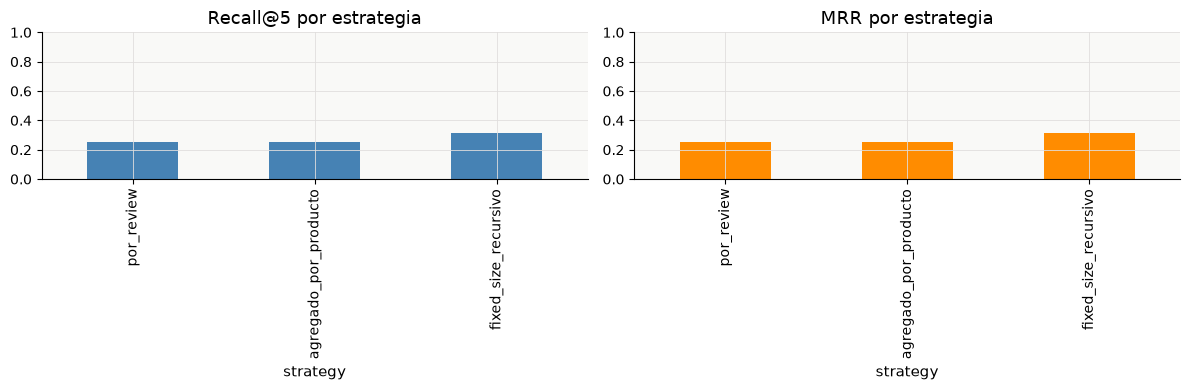

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df[f"recall@{TOP_K}"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title(f"Recall@{TOP_K} por estrategia")
axes[0].set_ylim(0, 1)

results_df["mrr"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("MRR por estrategia")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [39]:
results_df[["n_chunks", f"recall@{TOP_K}", "mrr"]]

,n_chunks,recall@5,mrr
strategy,,,
por_review,36189,0.2500,0.2500
agregado_por_producto,12968,0.2500,0.2500
fixed_size_recursivo,48164,0.3125,0.3125


### ¿Cómo definimos la estrategia ganadora?

- **Recall@k alto** = el producto correcto aparece entre los primeros k
  resultados casi siempre. Es la métrica más importante para un buscador.
- **MRR alto** = además de aparecer, aparece *arriba* en el ranking (no en el
  puesto 5 de 5).
- **`n_chunks`** = costo de indexar/mantener (más chunks = más costo de
  embeddings y de storage). Se usa como criterio de desempate.

En vez de completar esto a mano, la celda de abajo elige la estrategia
automáticamente aplicando esos tres criterios en orden.

In [40]:
# Elegimos automáticamente la estrategia ganadora:
# 1) mayor Recall@k (prioridad: que el producto correcto aparezca)
# 2) a igualdad de recall, mayor MRR (que aparezca arriba en el ranking)
# 3) a igualdad de ambas, menor n_chunks (más barata de indexar/mantener)
ranked = results_df.sort_values(
    by=[f"recall@{TOP_K}", "mrr", "n_chunks"],
    ascending=[False, False, True],
)
display(ranked)

STRATEGY_NAME = ranked.index[0]
STRATEGY_FN = strategies[STRATEGY_NAME]

winner = ranked.loc[STRATEGY_NAME]
print(
    f"\nEstrategia ganadora: '{STRATEGY_NAME}' "
    f"(Recall@{TOP_K}={winner[f'recall@{TOP_K}']:.3f}, "
    f"MRR={winner['mrr']:.3f}, n_chunks={int(winner['n_chunks'])})"
)

,recall@5,mrr,n_chunks
strategy,,,
fixed_size_recursivo,0.3125,0.3125,48164
agregado_por_producto,0.2500,0.2500,12968
por_review,0.2500,0.2500,36189



Estrategia ganadora: 'fixed_size_recursivo' (Recall@5=0.312, MRR=0.312, n_chunks=48164)


# Indexación

In [41]:
# Deduplicamos también el dataset completo (mismo criterio que usamos para
# elegir la estrategia de chunking) antes de indexar de verdad.
df_full_dedup = deduplicate_product_variants(df_full, VARIANT_MAP)

N_TOP_PRODUCTS = 300  
top_ids = (
    df_full_dedup.groupby("ProductId").size().sort_values(ascending=False).head(N_TOP_PRODUCTS).index
)
df_index = df_full_dedup[df_full_dedup["ProductId"].isin(top_ids)].copy()
print(f"Productos a procesar: {df_index['ProductId'].nunique()} | Reviews: {len(df_index)} de {len(df_full_dedup)} totales")

# Traemos los nombres inferidos que ya calculamos sobre df_dev (250 productos).
# Como acá tomamos los N_TOP_PRODUCTS productos con más reviews del dataset
# completo, es un conjunto distinto (con solapamiento parcial): algunos van
# a quedar sin nombre inferido todavía.
df_index = df_index.merge(name_lookup, on="ProductId", how="left")
df_index["product_name_inferred"] = df_index["product_name_inferred"].fillna("")

missing_names = df_index.loc[df_index["product_name_inferred"] == "", "ProductId"].unique()
print(f"Productos sin nombre inferido todavía: {len(missing_names)}")

for pid in tqdm(missing_names, desc="Infiriendo nombres faltantes"):
    nombre = infer_product_name(pid, df_index, max_reviews=10)
    df_index.loc[df_index["ProductId"] == pid, "product_name_inferred"] = nombre
    product_name_map[pid] = nombre  # mantenemos el mapa global actualizado

# Actualizamos name_lookup para que quede consistente con df_index
name_lookup = (
    df_index[["ProductId", "product_name_inferred"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

Filas antes de deduplicar variantes: 568454 | después: 516999 | eliminadas: 51455
Productos a procesar: 300 | Reviews: 73456 de 516999 totales
Productos sin nombre inferido todavía: 203


Infiriendo nombres faltantes: 100%|██████████| 203/203 [02:50<00:00,  1.19it/s]


# Generación de Descripción de Productos

In [42]:
import os
import time
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Falta OPENAI_API_KEY en el archivo .env")
client = OpenAI(api_key=api_key)

SYSTEM_PROMPT = """Sos un asistente que redacta descripciones breves y precisas de \
productos a partir de reviews reales de clientes.

Reglas:
1. Usá ÚNICAMENTE la información presente en las reviews. Nunca inventes \
ingredientes, certificaciones, usos o características que no estén \
mencionados explícitamente.
2. Si te paso un nombre sugerido del producto, usalo como referencia para \
saber de qué se trata, pero no lo repitas literalmente si no aporta.
3. Destacá 2 o 3 atributos concretos: sabor, textura, uso, empaque, precio, \
ingredientes o problemas frecuentes.
4. Si hay opiniones contradictorias sobre algo, reflejá esa ambigüedad en \
vez de elegir una sola versión.
5. Si las reviews disponibles son muy pocas, escribí una descripción breve \
y agregá al final: "(Información limitada: pocas reviews disponibles)".
6. No uses lenguaje de marketing exagerado ni frases vacías como "es una \
opción popular" o "muy valorado". Tono neutral e informativo.
7. Escribí en español, en 2 a 4 oraciones.
8. No menciones que la fuente son "reviews" ni "usuarios" en el texto final.
"""

In [43]:
def obtener_contexto_producto(product_id, df, max_reviews=15):
    """Arma el bloque de texto con las reviews más útiles de un producto,
    para pasarle al LLM como contexto."""
    reviews_producto = (
        df[df["ProductId"] == product_id]
        .sort_values("helpfulness_ratio", ascending=False)
        .head(max_reviews)
    )
    bloques = [
        f"- (Score {int(row.Score)}/5) {row.full_text}"
        for row in reviews_producto.itertuples()
    ]
    return "\n".join(bloques), len(reviews_producto)

In [44]:
def generar_descripcion(product_id, df, max_reviews=15, modelo="gpt-4o-mini", reintentos=3):
    contexto, n_reviews_usadas = obtener_contexto_producto(product_id, df, max_reviews)
    if not contexto:
        return None, 0

    nombre_sugerido = ""
    if "product_name_inferred" in df.columns:
        nombres = df.loc[df["ProductId"] == product_id, "product_name_inferred"].dropna()
        if len(nombres) > 0 and nombres.iloc[0]:
            nombre_sugerido = nombres.iloc[0]

    for intento in range(reintentos):
        try:
            response = client.chat.completions.create(
                model=modelo,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": (
                            f"Nombre sugerido del producto: {nombre_sugerido or 'No disponible'}\n\n"
                            f"Reviews del producto:\n{contexto}"
                        ),
                    },
                ],
                temperature=0.0,
                max_tokens=220,
            )
            return response.choices[0].message.content.strip(), n_reviews_usadas
        except Exception as e:
            print(f"Intento {intento + 1} falló para {product_id}: {e}")
            time.sleep(2 ** intento)
    return None, n_reviews_usadas

**No corran la corrida completa todavía.** Primero, sobre los productos del
`golden_set` + unos 40 más al azar, para revisar a mano si el prompt está
funcionando bien antes de gastar tokens en los `N_TOP_PRODUCTS` productos.

In [45]:
gold_ids = sorted(set(pid for item in golden_set for pid in item["relevant_product_ids"]))

# Sumamos productos al azar (con al menos 3 reviews, para no probar solo con
# casos triviales de 1 review), excluyendo los que ya están en el golden_set.
counts = df_index.groupby("ProductId").size()
candidatos = counts[counts >= 3].index.difference(gold_ids)
muestra_extra = pd.Series(candidatos).sample(min(40, len(candidatos)), random_state=42).tolist()

productos_a_validar = list(dict.fromkeys(gold_ids + muestra_extra))  # sin duplicados, preserva orden
print(f"Productos a validar: {len(productos_a_validar)} ({len(gold_ids)} del golden_set + {len(muestra_extra)} al azar)")

resultados_validacion = []
for pid in tqdm(productos_a_validar, desc="Generando descripciones (validación)"):
    descripcion, n_usadas = generar_descripcion(pid, df_index)
    resultados_validacion.append({
        "product_id": pid,
        "descripcion": descripcion,
        "n_reviews_usadas": n_usadas,
    })

df_validacion = pd.DataFrame(resultados_validacion)
df_validacion.head(15)

Productos a validar: 53 (13 del golden_set + 40 al azar)


Generando descripciones (validación): 100%|██████████| 53/53 [01:47<00:00,  2.04s/it]


,product_id,descripcion,n_reviews_usadas
0,B0009Z9FFW,NaN,0
1,B000EY7P96,NaN,0
2,B000F9J43K,NaN,0
3,B000VK8AVK,"Las Popchips destacan por su textura crujiente y ligera, lo que las convierte en una alternativa atractiva a los sna...",15
4,B0018CIOJ8,NaN,0
5,B001EO5Q64,Este aceite de coco virgen se destaca por su versatilidad en la cocina y el cuidado personal. Muchos lo utilizan par...,15
6,B001EO5QKA,NaN,0
7,B0026RQTGE,Este producto es un snack dental para perros que ayuda a mejorar la salud bucal y el aliento de las mascotas. Muchos...,15
8,B0029JZNES,NaN,0
9,B002C2ROCG,NaN,0


In [46]:
df_validacion

,product_id,descripcion,n_reviews_usadas
0,B0009Z9FFW,NaN,0
1,B000EY7P96,NaN,0
2,B000F9J43K,NaN,0
3,B000VK8AVK,"Las Popchips destacan por su textura crujiente y ligera, lo que las convierte en una alternativa atractiva a los sna...",15
4,B0018CIOJ8,NaN,0
5,B001EO5Q64,Este aceite de coco virgen se destaca por su versatilidad en la cocina y el cuidado personal. Muchos lo utilizan par...,15
6,B001EO5QKA,NaN,0
7,B0026RQTGE,Este producto es un snack dental para perros que ayuda a mejorar la salud bucal y el aliento de las mascotas. Muchos...,15
8,B0029JZNES,NaN,0
9,B002C2ROCG,NaN,0


In [47]:
df_validacion.to_csv("descripciones_validacion.csv", index=False)

In [48]:
df[df['ProductId']=='B001LG940E']['Text_clean'].values[0]

'disclaimer: i am a vine reviewer and therefore i received one item of this product for free to review. i have a marketing background and the marketing here is great, the switch is an ideal name and with consumers looking for healthy alternatives to sodas, this is a good switch ;-) this is a tasty beverage made from juice concentrates with no added sugars. to quench that thirst and you want the feel of carbonation (you know what i mean!) man, this is a good choice. my only gripe might be that it is tiny, just a cup or 8oz. it goes by quick. i have no idea on pricing, again since i m a vine reviewer, but it s going to need to be comparable to the price of regular sodas or cheaper, else why make the switch ? i do wish it came in 12, 16 or 20 oz variants. the black cherry flavor is good with no aftertaste and not too tart, essentially a good tasting soda that is not a soda and it still has carbonation.'

In [49]:
df_validacion[df_validacion['product_id']=='B001LG940E']['descripcion'].values[0]

'La bebida carbonatada de sabor a cereza negra ofrece una alternativa más saludable a los refrescos tradicionales, ya que está elaborada con jugo de fruta y sin jarabe de maíz de alta fructosa. Sin embargo, las opiniones sobre su sabor son variadas; algunos la describen como refrescante y con un toque de manzana, mientras que otros la consideran con un regusto extraño y poco representativa del sabor a cereza. Además, el tamaño de la lata (8.3 oz) ha sido criticado por ser pequeño en comparación con las latas de refresco convencionales, lo que puede hacer que su precio resulte elevado.'

In [50]:
df[df['ProductId']=='B000CQC04Q']

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Text_clean,Summary_clean,full_text_clean,review_length_clean,summary_length_clean,review_length,summary_length,helpfulness_ratio,full_text,product_name_inferred


In [51]:
df_validacion[df_validacion['product_id']=='B000CQC04Q']['descripcion'].values[0]

'Stash Tea ofrece una variedad de sabores que destacan por su calidad y precio accesible. Los clientes aprecian especialmente el sabor de las infusiones, como la de manzana canela, que combina aromas ricos y un equilibrio perfecto entre manzana y canela. Además, muchos mencionan que estas tés son agradables tanto calientes como fríos, y algunos destacan su efecto calmante y beneficios para la salud, como el apoyo al sistema inmunológico. El empaque también recibe comentarios positivos, ya que cada bolsa está sellada individualmente para preservar su frescura.'

In [52]:
df[df['ProductId']=='B001LG940E']['Text_clean'].values[0]

'disclaimer: i am a vine reviewer and therefore i received one item of this product for free to review. i have a marketing background and the marketing here is great, the switch is an ideal name and with consumers looking for healthy alternatives to sodas, this is a good switch ;-) this is a tasty beverage made from juice concentrates with no added sugars. to quench that thirst and you want the feel of carbonation (you know what i mean!) man, this is a good choice. my only gripe might be that it is tiny, just a cup or 8oz. it goes by quick. i have no idea on pricing, again since i m a vine reviewer, but it s going to need to be comparable to the price of regular sodas or cheaper, else why make the switch ? i do wish it came in 12, 16 or 20 oz variants. the black cherry flavor is good with no aftertaste and not too tart, essentially a good tasting soda that is not a soda and it still has carbonation.'

In [53]:
df_validacion[df_validacion['product_id']=='B001LG940E']['descripcion'].values[0]

'La bebida carbonatada de sabor a cereza negra ofrece una alternativa más saludable a los refrescos tradicionales, ya que está elaborada con jugo de fruta y sin jarabe de maíz de alta fructosa. Sin embargo, las opiniones sobre su sabor son variadas; algunos la describen como refrescante y con un toque de manzana, mientras que otros la consideran con un regusto extraño y poco representativa del sabor a cereza. Además, el tamaño de la lata (8.3 oz) ha sido criticado por ser pequeño en comparación con las latas de refresco convencionales, lo que puede hacer que su precio resulte elevado.'

In [54]:
df[df['ProductId']=='B000UBD88A']['Text_clean'].values[10]

'i actually love both systems but i find the senseo coffee to be easier on my stomach without a loss of flavor. the senseo pods are much easier to composite given there is no plastic in the container, just paper. however, the fact that there is somewhat less of a mess with the keurig pod, consumers are more apt to go with this convenience than with the recycling aspect. alas, we can not find senseo in our supermarkets anymore.'

In [55]:
df_validacion[df_validacion['product_id']=='B000UBD88A']['descripcion'].values[0]

'El café de tueste oscuro de Senseo se destaca por su sabor rico y agradable, con una textura cremosa que incluye una buena cantidad de espuma en cada taza. Es fácil de preparar, lo que lo convierte en una opción conveniente para disfrutar de una buena taza de café en cualquier momento. Además, muchos usuarios aprecian la posibilidad de recibirlo a domicilio, lo que evita la búsqueda en tiendas locales donde a menudo no está disponible. Sin embargo, algunos han notado un aumento en el precio por taza, lo que ha generado cierta insatisfacción.'

  **Revisión manual — checklist antes de escalar:**
- Elegí 5-10 filas al azar de `df_validacion` y compará la descripción contra
  las reviews originales del producto (`df_index[df_index.ProductId == pid]`).
- ¿Hay algo afirmado que ninguna review dice? → ajustar el prompt, ser más estricto.
- ¿Las descripciones son todas igual de genéricas, sin nada distintivo del
  producto? → puede ser que `temperature` esté muy baja, o que el contexto
  que le llega sea muy poco (revisar `n_reviews_usadas`).
- ¿El caso de "información limitada" se activa cuando corresponde (productos
  con pocas reviews)?

## Corrida completa (con checkpoint)

Si el prompt te convenció con la muestra chica, corré esto sobre todos los
`top_ids`. Guarda cada tanda en `descripciones_checkpoint.csv`, así si se
corta a la mitad (rate limit, se te cerró la compu, lo que sea) podés volver
a correr esta misma celda y retoma solo lo pendiente, sin gastar tokens de
más en lo que ya está hecho.

In [56]:
CHECKPOINT_PATH = "descripciones_checkpoint.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_descripciones = pd.read_csv(CHECKPOINT_PATH)
    ya_hechos = set(df_descripciones["product_id"])
else:
    df_descripciones = pd.DataFrame(columns=["product_id", "descripcion", "n_reviews_usadas"])
    ya_hechos = set()

pendientes = [pid for pid in top_ids if pid not in ya_hechos]
print(f"Ya generados: {len(ya_hechos)} | Pendientes: {len(pendientes)}")

resultados = []
for pid in tqdm(pendientes, desc="Generando descripciones"):
    descripcion, n_usadas = generar_descripcion(pid, df_index)
    resultados.append({"product_id": pid, "descripcion": descripcion, "n_reviews_usadas": n_usadas})

    # checkpoint cada 10 productos, para no perder trabajo si se corta el loop
    if len(resultados) % 10 == 0:
        df_tmp = pd.concat([df_descripciones, pd.DataFrame(resultados)], ignore_index=True)
        df_tmp.to_csv(CHECKPOINT_PATH, index=False)

    time.sleep(0.5)  # margen chico para no pegarle muy fuerte al rate limit; subilo si te tira 429

df_descripciones = pd.concat([df_descripciones, pd.DataFrame(resultados)], ignore_index=True)
df_descripciones = df_descripciones.dropna(subset=["descripcion"])
df_descripciones.to_csv(CHECKPOINT_PATH, index=False)
print(f"Total de descripciones generadas: {len(df_descripciones)}")
df_descripciones.head(10)

Ya generados: 378 | Pendientes: 0


Generando descripciones: 0it [00:00, ?it/s]

Total de descripciones generadas: 378


,product_id,descripcion,n_reviews_usadas
0,B007JFMH8M,"Las Galletas de Avena y Pasas Quaker Soft Baked son un snack suave y delicioso, ideal para cualquier momento del día...",15
1,B002QWP8H0,Los Greenies son un popular tratamiento dental para perros que muchos dueños consideran efectivos para mejorar el al...,15
2,B002QWHJOU,"Los Greenies son un popular tratamiento dental para perros, muy apreciado por su capacidad para ayudar a mantener el...",15
3,B002QWP89S,Los Greenies son un popular tratamiento dental para perros que muchos dueños consideran efectivos para mejorar el al...,15
4,B0026RQTGE,"Los Greenies son un popular tratamiento dental para perros, muy apreciado por su capacidad para ayudar a mantener el...",15
5,B003B3OOPA,El aceite de coco de Nature's Way es un producto versátil que se utiliza tanto en la cocina como en el cuidado perso...,15
6,B001EO5Q64,"El aceite de coco Nutiva es un producto versátil y de alta calidad, ideal tanto para la cocina como para el cuidado ...",15
7,B006HYLW32,"Popchips son una alternativa de snack que se destaca por su textura ligera y crujiente, similar a una mezcla entre u...",15
8,B001RVFERK,"Popchips son una alternativa de snack que se destaca por su textura ligera y crujiente, similar a una mezcla entre u...",15
9,B001RVFEP2,"Popchips son una alternativa más saludable a las papas fritas tradicionales, con una textura única y un sabor que ha...",15


### Alternativa opcional: pasar esto a un script separado

El checkpoint en CSV de arriba ya te protege de perder trabajo. Si en algún
momento esto crece mucho (miles de productos, corridas de horas) y preferís
no depender del notebook abierto, podés mover la misma lógica a un script
plano con una base relacional en vez de CSV:

```python
import sqlite3
import pandas as pd
from tqdm import tqdm
# ... importar generar_descripcion, SYSTEM_PROMPT, df_index igual que en este notebook

conn = sqlite3.connect("productos.db")
conn.execute("""
    CREATE TABLE IF NOT EXISTS descripciones (
        product_id TEXT PRIMARY KEY,
        descripcion TEXT,
        n_reviews_usadas INTEGER
    )
""")
conn.commit()

ya_procesados = {row[0] for row in conn.execute("SELECT product_id FROM descripciones")}
pendientes = [pid for pid in top_ids if pid not in ya_procesados]
print(f"Ya procesados: {len(ya_procesados)} | Pendientes: {len(pendientes)}")

for pid in tqdm(pendientes):
    descripcion, n_usadas = generar_descripcion(pid, df_index)
    if descripcion is not None:
        conn.execute(
            "INSERT OR REPLACE INTO descripciones VALUES (?, ?, ?)",
            (pid, descripcion, n_usadas),
        )
        conn.commit()  # commit por producto: más lento pero a prueba de cortes
```

No es necesario para este TP — el checkpoint en CSV alcanza. Lo dejo acá
como referencia si más adelante lo llevás a producción.

In [57]:
### Alternativa opcional: pasar esto a un script separado

import sqlite3
import pandas as pd
from tqdm import tqdm
# ... importar generar_descripcion, SYSTEM_PROMPT, df_index igual que en este notebook

conn = sqlite3.connect("productos.db")
conn.execute("""
    CREATE TABLE IF NOT EXISTS descripciones (
        product_id TEXT PRIMARY KEY,
        descripcion TEXT,
        n_reviews_usadas INTEGER
    )
""")
conn.commit()

ya_procesados = {row[0] for row in conn.execute("SELECT product_id FROM descripciones")}
pendientes = [pid for pid in top_ids if pid not in ya_procesados]
print(f"Ya procesados: {len(ya_procesados)} | Pendientes: {len(pendientes)}")

for pid in tqdm(pendientes):
    descripcion, n_usadas = generar_descripcion(pid, df_index)
    if descripcion is not None:
        conn.execute(
            "INSERT OR REPLACE INTO descripciones VALUES (?, ?, ?)",
            (pid, descripcion, n_usadas),
        )
        conn.commit()  # commit por producto: más lento pero a prueba de cortes

Ya procesados: 300 | Pendientes: 0


0it [00:00, ?it/s]


# Embedding y Retrieval final (Capa 2)

Con `df_descripciones` completo, embeddeamos cada descripción generada y la
indexamos en Chroma. Este es el índice que va a usar el agente para buscar
productos de cara al usuario final — distinto del índice de reviews que
usamos antes solo para *comparar estrategias de chunking*.

Usamos el mismo modelo local (`all-MiniLM-L6-v2`, vía `sentence-transformers`)
que ya estaba importado, en vez de embeddings de OpenAI: es gratis, no
depende de rate limits de la API, y para ~300 descripciones cortas la
diferencia de calidad no justifica el costo extra.

In [58]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

chroma_client = chromadb.PersistentClient(path="./chroma_db_productos")
try:
    chroma_client.delete_collection("product_search")
except Exception:
    pass
search_collection = chroma_client.create_collection("product_search")

df_search = df_descripciones.merge(name_lookup, left_on="product_id", right_on="ProductId", how="left")
df_search["product_name_inferred"] = df_search["product_name_inferred"].fillna("")

batch_size = 64
for i in tqdm(range(0, len(df_search), batch_size), desc="Indexando descripciones"):
    batch = df_search.iloc[i:i + batch_size]
    embeddings = embedding_model.encode(batch["descripcion"].tolist(), show_progress_bar=False).tolist()
    search_collection.add(
        ids=batch["product_id"].tolist(),
        documents=batch["descripcion"].tolist(),
        embeddings=embeddings,
        metadatas=[
            {"product_id": pid, "product_name": nombre}
            for pid, nombre in zip(batch["product_id"], batch["product_name_inferred"])
        ],
    )

print(f"Productos indexados para búsqueda: {search_collection.count()}")

Indexando descripciones: 100%|██████████| 6/6 [00:06<00:00,  1.05s/it]

Productos indexados para búsqueda: 378


# Métricas de Retrieval del índice final

Antes solo medimos qué tan bien se podía encontrar el producto correcto
buscando sobre las *reviews crudas* (para elegir estrategia de chunking).
Ahora medimos lo que realmente importa: qué tan bien el `search_collection`
—que busca sobre las descripciones generadas por el LLM— encuentra el
producto correcto para las preguntas del `golden_set`.

In [59]:
def evaluate_search_collection(collection, golden_set, embedding_model, top_k=5):
    """Recall@k y MRR de un chroma collection contra un golden_set de
    preguntas -> product_ids relevantes. Asume que cada metadata tiene
    'product_id'."""
    hits, reciprocal_ranks = [], []

    for item in golden_set:
        query_emb = embedding_model.encode([item["question"]]).tolist()
        res = collection.query(query_embeddings=query_emb, n_results=top_k)
        retrieved_ids = res["ids"][0]
        relevant = set(item["relevant_product_ids"])

        hits.append(any(pid in relevant for pid in retrieved_ids))

        rr = 0.0
        for rank, pid in enumerate(retrieved_ids, start=1):
            if pid in relevant:
                rr = 1 / rank
                break
        reciprocal_ranks.append(rr)

    return {
        f"recall@{top_k}": sum(hits) / len(hits),
        "mrr": sum(reciprocal_ranks) / len(reciprocal_ranks),
    }


TOP_K_FINAL = 5
metrics_final = evaluate_search_collection(search_collection, golden_set, embedding_model, top_k=TOP_K_FINAL)
print("Métricas del índice final (búsqueda sobre descripciones generadas):")
metrics_final

Métricas del índice final (búsqueda sobre descripciones generadas):


{'recall@5': 0.0625, 'mrr': 0.03125}

# Agente (LangChain + LangGraph)

Grafo simple de 2 nodos: `retrieve` (busca en `search_collection`) →
`generate` (LLM responde usando solo lo que se recuperó). Para instalar lo
que falta, agregá a `requirements.txt`:

```
langgraph
langchain-core
langchain-openai
```

In [60]:
%pip install langchain_openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
from typing import TypedDict, List, Dict, Any
import json

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END

from sentence_transformers import CrossEncoder

In [70]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=api_key
)

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7316.50it/s]


In [71]:
class AgentState(TypedDict):
    question: str

    filters: Dict[str, Any]

    retrieved: List[Dict[str, Any]]

    reranked: List[Dict[str, Any]]

    relevant_docs: List[Dict[str, Any]]

    answer: str

In [72]:
FILTER_PROMPT = """
Extraé información útil de la consulta.

Respondé únicamente un JSON.

Formato:

{
    "product_name":"",
    "min_score": null
}

Ejemplos:

Consulta:
Quiero un buen café

Respuesta:
{
    "product_name":"café",
    "min_score": null
}

Consulta:
Busco chocolates de 5 estrellas

Respuesta:
{
    "product_name":"chocolate",
    "min_score":5
}

Consulta:
Quiero cualquier producto

Respuesta:
{
    "product_name":"",
    "min_score":null
}
"""

In [73]:
def extract_filters_node(state: AgentState):

    print("\n========== EXTRACT FILTERS ==========")

    messages = [
        SystemMessage(content=FILTER_PROMPT),
        HumanMessage(content=state["question"])
    ]

    response = llm.invoke(messages)

    try:
        filters = json.loads(response.content)
    except Exception:
        filters = {
            "product_name": "",
            "min_score": None
        }

    print(filters)

    return {
        "filters": filters
    }

In [86]:
def retrieve_node(state: AgentState):

    print("\n========== RETRIEVE ==========")

    query_embedding = embedding_model.encode(
        [state["question"]]
    ).tolist()

    results = search_collection.query(
        query_embeddings=query_embedding,
        n_results=20
    )

    retrieved = []

    for pid, meta, doc in zip(
        results["ids"][0],
        results["metadatas"][0],
        results["documents"][0]
    ):

        retrieved.append({
            "product_id": pid,
            "product_name": meta.get("product_name", ""),
            "description": doc
        })
    print("\nPrimeros productos recuperados:")

    for r in retrieved[:10]:
        print(r["product_name"])
    print(f"Documentos recuperados: {len(retrieved)}")

    return {
        "retrieved": retrieved
    }

    print(f"Documentos recuperados: {len(retrieved)}")

    return {
            "retrieved": retrieved
        }

el flujo hasta aca:

extract_filters ✔

↓

retrieve ✔

↓

rerank ← siguiente paso

↓

grade

↓

generate

El CrossEncoder no genera embeddings. Lo que hace es leer la pregunta + cada documento juntos y asignar un score de relevancia. Es mucho más preciso que la búsqueda vectorial.

In [87]:
def rerank_node(state: AgentState):

    print("\n========== RERANK ==========")

    retrieved = state["retrieved"]

    if len(retrieved) == 0:
        print("No hay documentos para rerankear.")
        return {"reranked": []}

    # Crear pares (pregunta, documento)
    sentence_pairs = [
        (state["question"], doc["description"])
        for doc in retrieved
    ]

    # Obtener scores del CrossEncoder
    scores = reranker.predict(sentence_pairs)

    # Agregar score a cada documento
    reranked = []

    for doc, score in zip(retrieved, scores):

        new_doc = doc.copy()
        new_doc["rerank_score"] = float(score)

        reranked.append(new_doc)

    # Ordenar por score
    reranked = sorted(
        reranked,
        key=lambda x: x["rerank_score"],
        reverse=True
    )

    # Quedarse con los 5 mejores
    reranked = reranked[:5]

    print("Top scores:")

    for doc in reranked:
        print(
            f"{doc['rerank_score']:.3f} - {doc['product_name']}"
        )

    return {
        "reranked": reranked
    }

¿Qué hace este nodo?

Si Chroma devuelve:

Producto	Similaridad
Café A	✅
Chocolate	✅
Té	✅
Galletitas	✅
Cereal	✅

el CrossEncoder vuelve a leer:

Pregunta:
Quiero un café intenso

junto con cada descripción:

Pregunta + descripción del Café A
Pregunta + descripción del Chocolate
Pregunta + descripción del Té

0.98 Café A

0.91 Café B

0.81 Espresso

0.23 Té

0.05 Chocolate

Así descartamos documentos que el embedding recuperó por similitud general pero que no responden realmente a la consulta.

In [88]:
state = {
    "question": "Quiero un café intenso",
    "filters": {},
}

state.update(retrieve_node(state))
state.update(rerank_node(state))

for doc in state["reranked"]:
    print(doc["rerank_score"], "-", doc["product_name"])


========== RETRIEVE ==========

Primeros productos recuperados:
illy issimo cappuccino
Gloria Jean's Butter Toffee K-Cups

senseo dark roast coffee
Gloria Jean's Butter Toffee K-Cups

Timothy's Breakfast Blend Coffee K-Cups
Douwe Egberts Dark Roast Pods
Green Mountain Double Black Diamond K-Cups
Green Mountain Double Black Diamond K-Cups
Documentos recuperados: 20

========== RERANK ==========


Top scores:
6.122 - Nantucket Blend K-Cup
6.122 - Nantucket Blend K-Cup
6.122 - Nantucket Blend K-Cup Coffee
6.122 - Nantucket Blend K-Cup Coffee
2.906 - Green Mountain Double Black Diamond K-Cups
6.122254848480225 - Nantucket Blend K-Cup
6.122254848480225 - Nantucket Blend K-Cup
6.122254848480225 - Nantucket Blend K-Cup Coffee
6.122254848480225 - Nantucket Blend K-Cup Coffee
2.906141757965088 - Green Mountain Double Black Diamond K-Cups


✅ Chroma recupera documentos.
✅ El CrossEncoder está ordenando correctamente.
✅ El flujo hasta rerank funciona.

In [94]:
GRADER_PROMPT = """
Sos un evaluador de documentos para un sistema RAG.

Tu tarea es puntuar cada documento según qué tan útil es para responder la consulta del usuario.

Asigná un score entre 0 y 10.

0 = completamente irrelevante

10 = responde perfectamente.

Respondé únicamente un JSON.

Formato:

[
  {
    "document":1,
    "score":9
  }
]

No agregues texto.
"""

In [1]:
def grade_node(state: AgentState):

    print("\n========== GRADE ==========")

    docs = state["reranked"]

    if len(docs) == 0:
        return {"relevant_docs": []}

    docs_text = ""

    for i, doc in enumerate(docs, start=1):

        docs_text += f"""
Documento {i}

Producto:
{doc["product_name"]}

Descripción:
{doc["description"]}

--------------------
"""

    messages = [
        SystemMessage(content=GRADER_PROMPT),
        HumanMessage(
            content=f"""
Pregunta:

{state["question"]}

Documentos:

{docs_text}
"""
        ),
    ]

    response = llm.invoke(messages)

    print(response.content)

    try:
        grades = json.loads(response.content)

    except Exception:

        print("No pude parsear el JSON.")

        return {
            "relevant_docs": docs
        }

    relevant_docs = []

    for grade, doc in zip(grades, docs):

        score = grade.get("score", 0)

    if score >= 7:
        relevant_docs.append(doc)

        print(f"Documentos relevantes: {len(relevant_docs)}")
    for grade, doc in zip(grades, docs):

        doc["grade_score"] = grade["score"]

        if grade["score"] >= 7:
            relevant_docs.append(doc)

    return {
        "relevant_docs": relevant_docs
    }

NameError: name 'AgentState' is not defined

In [97]:
state.update(
    grade_node(state)
)

print(len(state["relevant_docs"]))


========== GRADE ==========
[
  {
    "document": 1,
    "score": 2
  },
  {
    "document": 2,
    "score": 2
  },
  {
    "document": 3,
    "score": 2
  },
  {
    "document": 4,
    "score": 2
  },
  {
    "document": 5,
    "score": 10
  }
]
Documentos relevantes: 1
2


In [98]:
for i, doc in enumerate(state["reranked"]):
    print("=" * 80)
    print(i)
    print("Producto:", doc["product_name"])
    print("Score reranker:", doc["rerank_score"])
    print(doc["description"][:500])

0
Producto: Nantucket Blend K-Cup
Score reranker: 6.122254848480225
El Nantucket Blend K-Cup Coffee es un café de tueste medio que se destaca por su sabor suave y cremoso, con notas sutiles que algunos describen como un toque de vainilla. Es fácil de digerir y no deja un regusto amargo, lo que lo convierte en una opción agradable para quienes prefieren un café menos intenso. Aunque muchos lo consideran su favorito, hay opiniones que sugieren que puede resultar débil para quienes buscan un sabor más robusto. (Información limitada: pocas reviews disponibles)
1
Producto: Nantucket Blend K-Cup
Score reranker: 6.122254848480225
El Nantucket Blend K-Cup Coffee es un café de tueste medio que se destaca por su sabor suave y cremoso, con notas sutiles que algunos describen como un toque de vainilla. Es fácil de digerir y no deja un regusto amargo, lo que lo convierte en una opción agradable para quienes prefieren un café menos intenso. Aunque muchos lo consideran su favorito, hay opiniones que 

In [92]:
print(state["reranked"][0]["description"])

El Nantucket Blend K-Cup Coffee es un café de tueste medio que se destaca por su sabor suave y cremoso, con notas sutiles que algunos describen como un toque de vainilla. Es fácil de digerir y no deja un regusto amargo, lo que lo convierte en una opción agradable para quienes prefieren un café menos intenso. Aunque muchos lo consideran su favorito, hay opiniones que sugieren que puede resultar débil para quienes buscan un sabor más robusto. (Información limitada: pocas reviews disponibles)


In [93]:
print(state["reranked"][4]["description"])

Este café en cápsulas se caracteriza por su sabor fuerte y audaz, siendo una opción destacada para quienes prefieren un café robusto. Muchos lo describen como un excelente café de tueste oscuro, con un ligero toque de amargor, aunque algunos lo consideran casi demasiado fuerte. El empaque ha recibido críticas mixtas, ya que algunos usuarios mencionan que las cápsulas llegan sin protección adecuada, lo que puede resultar en daños.


In [ ]:
df 

In [100]:

"""
Versión mejorada del agente RAG para Amazon Fine Food Reviews.
Requiere:
- api_key
- embedding_model (SentenceTransformer)
- search_collection (Chroma)
- df (DataFrame original con ProductId, Score, full_text_clean, product_name_inferred)
"""
from typing import TypedDict, List, Dict, Any
import json
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from sentence_transformers import CrossEncoder

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, api_key=api_key)
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Score promedio por producto
product_scores = (
    df.groupby("ProductId")["Score"]
      .mean()
      .to_dict()
)

class AgentState(TypedDict):
    question:str
    filters:Dict[str,Any]
    retrieved:List[Dict[str,Any]]
    reranked:List[Dict[str,Any]]
    relevant_docs:List[Dict[str,Any]]
    answer:str

FILTER_PROMPT = """
Extraé información de la consulta.

Respondé SOLO JSON.

Formato:

{
    "keywords":[]
}

Ejemplos

Consulta:
Quiero un café intenso

Respuesta:
{
    "keywords":[
        "coffee",
        "strong",
        "dark roast"
    ]
}

Consulta:
Quiero chocolate sin azúcar

Respuesta:
{
    "keywords":[
        "chocolate",
        "sugar free"
    ]
}
"""

GEN_PROMPT = """
Sos un asistente experto en productos alimenticios.

Reglas:

- Respondé únicamente usando el contexto.
- No inventes productos.
- Explicá por qué recomendás cada producto.
- Si hay varias opciones, ordenalas de mejor a peor.
- Si no hay suficiente evidencia, decilo.
- Respondé en español.
"""
def ask(question):

    result = agent.invoke({
        "question": question
    })

    print("\n==============================")
    print(result["answer"])

    return result

def extract_filters_node(state):

    print("\n========== FILTERS ==========")

    response = llm.invoke([
        SystemMessage(content=FILTER_PROMPT),
        HumanMessage(content=state["question"])
    ])

    try:
        filters = json.loads(response.content)
    except:
        filters = {"keywords":[]}

    print(filters)

    return {
        "filters": filters
    }

def retrieve_node(state):
    emb=embedding_model.encode([state["question"]]).tolist()
    res=search_collection.query(query_embeddings=emb,n_results=30)
    docs=[]
    seen=set()
    for pid,meta,doc in zip(res["ids"][0],res["metadatas"][0],res["documents"][0]):
        if pid in seen:
            continue
        seen.add(pid)
        docs.append({
            "product_id":pid,
            "product_name":meta.get("product_name",""),
            "description":doc,
            "avg_score":product_scores.get(pid,None)
        })
    
    return {"retrieved":docs}

def rerank_node(state):
    pairs=[(state["question"],f"Producto:{d['product_name']}\n{d['description']}") for d in state["retrieved"]]
    scores=reranker.predict(pairs)
    docs=[]
    for d,s in zip(state["retrieved"],scores):
        x=d.copy()
        x["rerank_score"]=float(s)
        docs.append(x)
    docs=sorted(docs,key=lambda x:(x["rerank_score"],x["avg_score"] or 0),reverse=True)[:3]
    return {"reranked":docs}

def grade_node(state):
    # Solo logging
    for d in state["reranked"]:
        print(f"{d['product_name']} | rerank={d['rerank_score']:.2f} | rating={d['avg_score']}")
    return {"relevant_docs":state["reranked"]}

def generate_node(state):
    docs=state["relevant_docs"]
    if not docs:
        return {"answer":"No encontré productos relevantes."}
    context="\n\n".join(
        f"Producto: {d['product_name']}\nRating promedio:{d['avg_score']}\nDescripción:{d['description']}"
        for d in docs
    )
    ans=llm.invoke([
        SystemMessage(content=GEN_PROMPT),
        HumanMessage(content=f"Pregunta:{state['question']}\n\nContexto:\n{context}")
    ])
    return {"answer":ans.content}

graph=StateGraph(AgentState)
for n,f in [("extract_filters",extract_filters_node),("retrieve",retrieve_node),
("rerank",rerank_node),("grade",grade_node),("generate",generate_node)]:
    graph.add_node(n,f)
graph.add_edge(START,"extract_filters")
graph.add_edge("extract_filters","retrieve")
graph.add_edge("retrieve","rerank")
graph.add_edge("rerank","grade")
graph.add_edge("grade","generate")
graph.add_edge("generate",END)
agent=graph.compile()


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 14983.73it/s]


In [101]:
ask("Quiero un café intenso")


========== FILTERS ==========
{'keywords': ['café', 'intenso']}
Nantucket Blend K-Cup | rerank=5.96 | rating=None
Nantucket Blend K-Cup | rerank=5.96 | rating=None
Nantucket Blend K-Cup Coffee | rerank=5.86 | rating=None

Basado en la información proporcionada, el Nantucket Blend K-Cup Coffee no es una opción recomendada si buscas un café intenso. Este producto se caracteriza por ser un café de tueste medio, con un sabor suave y cremoso, lo que lo hace más adecuado para quienes prefieren un café menos robusto. Además, hay opiniones que sugieren que puede resultar débil para quienes buscan un sabor más fuerte.

Dado que no hay otras opciones disponibles en el contexto y todas las descripciones son idénticas, no puedo ofrecerte una lista ordenada de productos. Sin embargo, te sugiero que busques cafés de tueste oscuro o espresso, que suelen tener un sabor más intenso y robusto, ya que el Nantucket Blend K-Cup no cumple con tus expectativas de intensidad.


{'question': 'Quiero un café intenso',
 'filters': {'keywords': ['café', 'intenso']},
 'retrieved': [{'product_id': 'B002IEVJRY',
   'product_name': 'illy issimo cappuccino',
   'description': 'El illy issimo Cappuccino es una bebida de café enlatada que combina café, leche baja en grasa, azúcar y cacao en polvo. Su sabor es descrito como fuerte y cremoso, aunque algunos lo encuentran un poco amargo o demasiado dulce. La mayoría de los consumidores aprecian su frescura y la conveniencia de tenerlo frío, aunque algunos prefieren disfrutarlo caliente. Con 100 calorías por lata y 81 mg de cafeína, es una opción que puede ser ideal para quienes buscan un impulso de energía en cualquier momento del día. \n\n(Información limitada: pocas reviews disponibles)',
   'avg_score': 3.7324380165289255},
  {'product_id': 'B002HQLY7S',
   'product_name': "Gloria Jean's Butter Toffee K-Cups",
   'description': 'Este café en K-Cup ofrece un sabor a mantequilla de toffee que algunos consideran agradable 